# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [73]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [75]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数

In [ ]:
instrument_id = '518880'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 2,
    'open_confidence': 0.4,
    'close_confidence': 0.6,
    'standard_num': 1000,
    'trailing_stop_pct': 0.001,
    'max_pct': 0.004,
    'min_pct': 0.001,

    'k_pct': 1,
    'k_up': 3,
    'k_down': 3
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [77]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

train_dates, valid_dates, test_dates = split_dates(trade_dates)

总交易日数量: 54
交易日范围: 20260105 ~ 20260327
训练集: 20260105 ~ 20260302 (35天)
验证集: 20260303 ~ 20260313 (9天)
测试集: 20260316 ~ 20260327 (10天)


## 生成训练数据

In [78]:
print("生成训练集样本...")
X_train, y_train = samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")
if len(y_train) > 0:
    print(f"标签分布:\n{y_train.value_counts()}")

生成训练集样本...
20260105: 产生 781 个样本
20260106: 产生 767 个样本
20260107: 产生 798 个样本
20260108: 产生 819 个样本
20260109: 产生 755 个样本
20260112: 产生 754 个样本
20260113: 产生 779 个样本
20260114: 产生 812 个样本
20260115: 产生 789 个样本
20260116: 产生 753 个样本
20260119: 产生 752 个样本
20260120: 产生 810 个样本
20260121: 产生 794 个样本
20260122: 产生 748 个样本
20260123: 产生 781 个样本
20260126: 产生 858 个样本
20260127: 产生 791 个样本
20260128: 产生 802 个样本
20260129: 产生 812 个样本
20260130: 产生 884 个样本
20260202: 产生 757 个样本
20260203: 产生 833 个样本
20260204: 产生 812 个样本
20260205: 产生 834 个样本
20260206: 产生 839 个样本
20260209: 产生 814 个样本
20260210: 产生 781 个样本
20260211: 产生 745 个样本
20260212: 产生 737 个样本
20260213: 产生 772 个样本
20260224: 产生 752 个样本
20260225: 产生 777 个样本
20260226: 产生 774 个样本
20260227: 产生 745 个样本
20260302: 产生 821 个样本
训练集样本: X=(27632, 10), y=(27632,)
标签分布:
0    19665
1     7967
Name: count, dtype: int64


In [79]:
print("生成验证集样本...")
X_valid, y_valid = samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")
if len(y_valid) > 0:
    print(f"标签分布:\n{y_valid.value_counts()}")

生成验证集样本...
20260303: 产生 794 个样本
20260304: 产生 886 个样本
20260305: 产生 807 个样本
20260306: 产生 780 个样本
20260309: 产生 804 个样本
20260310: 产生 783 个样本
20260311: 产生 763 个样本
20260312: 产生 759 个样本
20260313: 产生 750 个样本
验证集样本: X=(7126, 10), y=(7126,)
标签分布:
0    4995
1    2131
Name: count, dtype: int64


## 训练模型

In [80]:
model = train_model(X_train, y_train, X_valid, y_valid, param_dict)

[0]	validation_0-logloss:0.69330
[1]	validation_0-logloss:0.69271
[2]	validation_0-logloss:0.69212
[3]	validation_0-logloss:0.69157
[4]	validation_0-logloss:0.69156
[5]	validation_0-logloss:0.69092
[6]	validation_0-logloss:0.69030
[7]	validation_0-logloss:0.68977
[8]	validation_0-logloss:0.68906
[9]	validation_0-logloss:0.68843
[10]	validation_0-logloss:0.68794
[11]	validation_0-logloss:0.68742
[12]	validation_0-logloss:0.68685
[13]	validation_0-logloss:0.68627
[14]	validation_0-logloss:0.68565
[15]	validation_0-logloss:0.68518
[16]	validation_0-logloss:0.68496
[17]	validation_0-logloss:0.68453
[18]	validation_0-logloss:0.68405
[19]	validation_0-logloss:0.68409
[20]	validation_0-logloss:0.68413
[21]	validation_0-logloss:0.68426
[22]	validation_0-logloss:0.68387
[23]	validation_0-logloss:0.68336
[24]	validation_0-logloss:0.68288
[25]	validation_0-logloss:0.68243
[26]	validation_0-logloss:0.68198
[27]	validation_0-logloss:0.68158
[28]	validation_0-logloss:0.68115
[29]	validation_0-loglos

## 测试模型

In [81]:
print("生成测试集样本...")
X_test, y_test = samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")
if len(y_test) > 0:
    print(f"标签分布:\n{y_test.value_counts()}")

accuracy = evaluate_model(model, X_test, y_test)

生成测试集样本...


20260316: 产生 755 个样本
20260317: 产生 762 个样本
20260318: 产生 795 个样本
20260319: 产生 792 个样本
20260320: 产生 815 个样本
20260323: 产生 844 个样本
20260324: 产生 842 个样本
20260325: 产生 783 个样本
20260326: 产生 862 个样本
20260327: 产生 787 个样本
测试集样本: X=(8037, 10), y=(8037,)
标签分布:
0    5659
1    2378
Name: count, dtype: int64
测试集准确率: 0.6662

分类报告:
              precision    recall  f1-score   support

           0       0.76      0.77      0.76      5659
           1       0.43      0.42      0.42      2378

    accuracy                           0.67      8037
   macro avg       0.60      0.59      0.59      8037
weighted avg       0.66      0.67      0.66      8037



测试集准确率: 0.6662

分类报告:
              precision    recall  f1-score   support

           0       0.76      0.77      0.76      5659
           1       0.43      0.42      0.42      2378

    accuracy                           0.67      8037
   macro avg       0.60      0.59      0.59      8037
weighted avg       0.66      0.67      0.66      8037

## 创建策略实例

In [82]:
strategy = StrategyDemo(model, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1


## 使用backtesting工具进行回测

日期 20260303 完成，盈亏: 12.00, 成交: 46次
日期 20260304 完成，盈亏: 6.80, 成交: 58次
日期 20260305 完成，盈亏: 5.20, 成交: 37次
日期 20260306 完成，盈亏: 1.50, 成交: 20次

instrument_id 511090
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
20260305
20260306
20260309
20260310
20260311
20260312
20260313
20260316
20260317
20260318
20260319
20260320
20260323
20260324
20260325
20260326
20260327

instrument_id 511100
20260105
20260106
20260107
20260108
20260109
20260112
20260113
20260114
20260115
20260116
20260119
20260120
20260121
20260122
20260123
20260126
20260127
20260128
20260129
20260130
20260202
20260203
20260204
20260205
20260206
20260209
20260210
20260211
20260212
20260213
20260224
20260225
20260226
20260227
20260302
20260303
20260304
2026

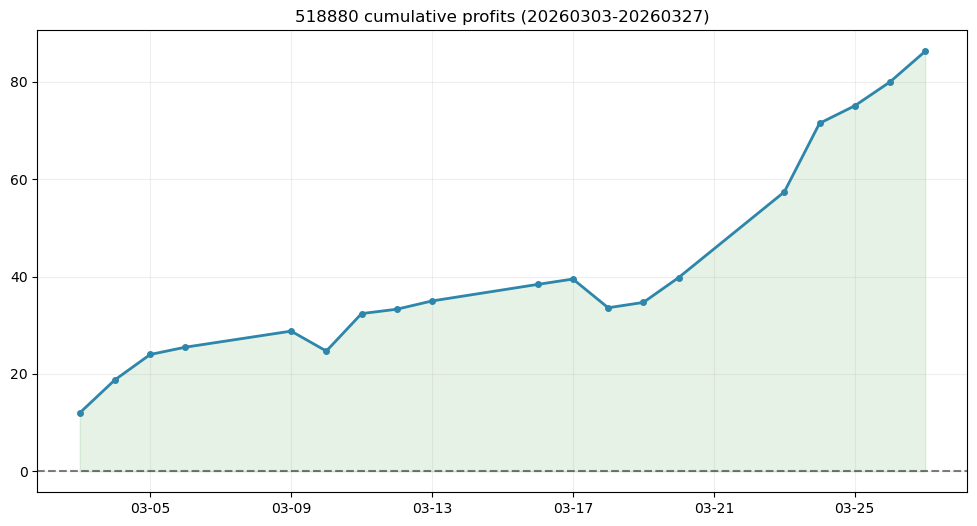

{'测试天数': 19, '累计总盈亏': np.float64(86.3), '总成交次数': 624, '日均盈亏': np.float64(4.54), '胜率(天)%': 89.47, '盈亏比(日均)': np.float64(1.13), '最大单日盈利': 17.6, '最大单日亏损': -5.9, '每笔交易平均盈利': np.float64(0.14)}


In [83]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from backtesting import backtest_multi_days, backtest_summary

result_df = backtest_multi_days(
    instrument_id=instrument_id,
    start_ymd='20260303',
    end_ymd='20260327',
    strategy=strategy,
    param_dict=param_dict
)

summary = backtest_summary(result_df)
print(summary)

In [84]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(result_df)

,trade_ymd,profits,trades,final_pos,trade_date
0,20260303,12.0,46,0,2026-03-03
1,20260304,6.8,58,0,2026-03-04
2,20260305,5.2,37,0,2026-03-05
3,20260306,1.5,20,0,2026-03-06
4,20260309,3.3,41,0,2026-03-09
5,20260310,-4.1,21,0,2026-03-10
6,20260311,7.7,14,0,2026-03-11
7,20260312,0.9,24,0,2026-03-12
8,20260313,1.7,20,0,2026-03-13
9,20260316,3.4,31,0,2026-03-16


## 保存回测结果

In [85]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果
result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_20260408_074135
回测结果已保存到: /home/jovyan/work/tactics_demo/delta/backtest_result/518880_delta_v1_20260408_074135
文件夹包含以下文件:
  - summary.json
  - parameters.json
  - README.md


## 单日回测观察

In [86]:
instrument_id = '518880'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 2,
    'confidence_threshold': 0.4,
    'standard_num': 1000,
    'trailing_stop_pct': 0.001,
    'max_pct': 0.004,
    'min_pct': 0.001,

    'k_pct': 1.5,
    'k_up': 3,
    'k_down': 3
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])
strategy = StrategyDemo(model, param_dict)

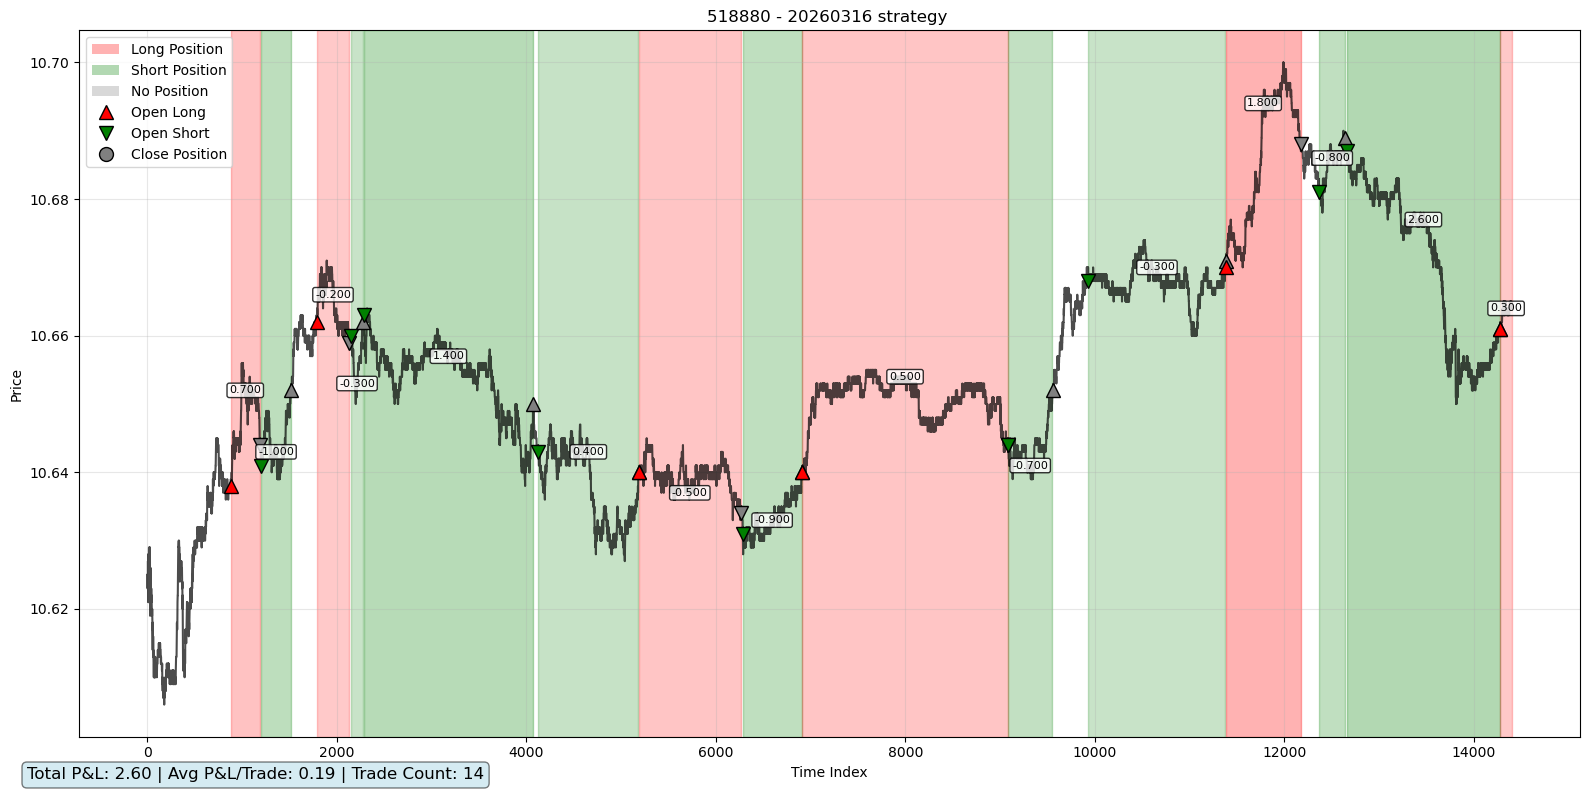

In [87]:
from single_day_backtest import single_day_backtest
hh = single_day_backtest(instrument_id,'20260316',strategy)